# Basics of CCD Photometry

This guide introduces the practical ideas needed to turn astronomical images into brightness measurements. The goal is not to cover every advanced reduction method. The goal is to help you understand what the detector records, what can go wrong, how calibration frames help, and how a calibrated image becomes a differential light curve.

## What Photometry Measures

Photometry means measuring the brightness of an object. In time-series photometry, we measure brightness repeatedly so that we can make a light curve. A light curve is a graph of brightness versus time. Eclipsing binaries, transiting exoplanets, pulsating stars, rotating asteroids, and cataclysmic variables can all produce measurable changes in brightness.

The key point is that an astronomical image is not just a picture. It is a numerical dataset. Each pixel stores a number related to the amount of light detected during the exposure.

```{admonition} Practical definition
:class: note

In this guide, photometry means measuring how much light from a target falls inside a chosen aperture, subtracting the local sky background, and comparing the result to one or more comparison stars.
```

## How a Digital Photometer Works

A traditional photoelectric photometer measured one star at a time through a filter and aperture. Modern CCD/CMOS photometry usually works differently: the camera records a full image, and software defines the aperture afterward. In that sense, the image plus software becomes the photometer.

The basic chain is:

```text
photons from star
→ telescope collects photons
→ filter selects a wavelength range
→ detector converts photons to electrons
→ electronics convert charge to digital counts
→ calibration removes instrumental patterns
→ aperture photometry measures source counts
→ differential photometry compares target and comparison stars
```

A detector does not directly record "brightness." It records a number of counts in each pixel. These counts are usually stored in **ADU**, or analog-to-digital units. The gain of the camera relates ADU to electrons. For example, a gain of $1.5\ {\rm e^-}/{\rm ADU}$ means that one ADU corresponds to about 1.5 detected electrons.

```{admonition} Important
:class: warning

The detector records the target, the sky background, electronic offsets, thermal signal, pixel-response variations, cosmic rays, and noise. Photometry is the process of separating the useful target signal from everything else as carefully as possible.
```

## From Counts to Instrumental Magnitudes

After the sky background has been subtracted, the total source counts inside the aperture are proportional to the flux from the star. A common instrumental magnitude is

$$m_{\rm inst} = -2.5\log_{10}\left(\frac{F}{t_{\rm exp}}\right),$$

where $F$ is the background-subtracted source signal and $t_{\rm exp}$ is the exposure time. The exposure-time normalization allows images with different exposure times to be compared more consistently.

The magnitude scale is backwards. A brighter object has a smaller magnitude. If the source flux increases, the instrumental magnitude becomes more negative.

```{admonition} Checkpoint
:class: tip margin

Two stars are measured in the same calibrated image. Star A has four times the flux of Star B. Which star has the smaller instrumental magnitude?
```

## Aperture Photometry

Aperture photometry measures the light from a source by summing pixel values inside a region centered on the star. A surrounding sky annulus estimates the local sky background. The sky contribution inside the aperture is then subtracted.

The essential measurement is

$$F_{\star} = \sum_{\rm aperture} I_i - n_{\rm aperture}\,\widetilde{S}_{\rm sky},$$

where $\displaystyle \sum_{\rm aperture} I_i$ is the sum of pixel values inside the source aperture, $n_{\rm aperture}$ is the number of pixels in the aperture, and $\widetilde{S}_{\rm sky}$ is a representative sky value per pixel estimated from the sky annulus.

- Use an aperture large enough to include most of the star's light but not so large that unnecessary sky noise is added. 
- Use a sky annulus that samples nearby background without including the target, obvious neighboring stars, or bad pixels.

```{admonition} Beginner rule
:class: tip

For isolated stars, start with an aperture radius comparable to a few times the typical star width. Then test whether the measured flux changes strongly when you slightly increase or decrease the aperture. Stable photometry should not depend wildly on a tiny aperture adjustment.
```

The estimated sky background is 100.20 counts per pixel.
The background-subtracted source flux is 39050.7 counts.
The instrumental magnitude is -11.479.


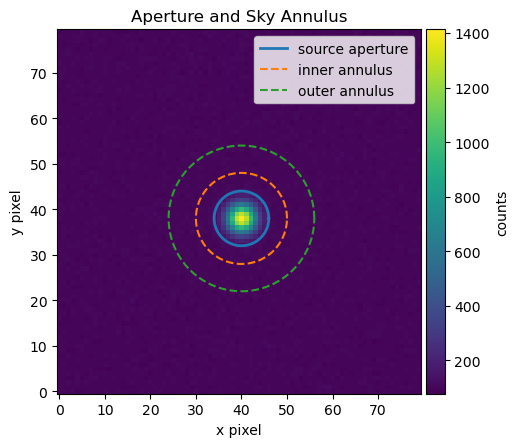

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Simulate a small calibrated image with one star and a nearly flat sky background.
rng = np.random.default_rng(42)
ny, nx = 80, 80
y, x = np.mgrid[0:ny, 0:nx]
sky_level = 100.0

# Define the star position and shape.
x_star, y_star = 40.0, 38.0
star_sigma = 2.2
star_flux = 40000.0

# Create a 2D Gaussian star profile.
star = star_flux / (2 * np.pi * star_sigma**2) * np.exp(-((x - x_star)**2 + (y - y_star)**2) / (2 * star_sigma**2))

# Final simulated image.
image_data = sky_level + star + rng.normal(0, 5, size=(ny, nx))

# Define a circular source aperture and a circular sky annulus.
r_ap = 6.0
r_in = 10.0
r_out = 16.0
r = np.sqrt((x - x_star)**2 + (y - y_star)**2)
aperture_mask = r <= r_ap
annulus_mask = (r >= r_in) & (r <= r_out)

# Estimate sky from the annulus and subtract it from the aperture sum.
sky_per_pixel = np.median(image_data[annulus_mask])
aperture_sum = np.sum(image_data[aperture_mask])
source_flux = aperture_sum - aperture_mask.sum() * sky_per_pixel
m_inst = -2.5 * np.log10(source_flux)

print(f"The estimated sky background is {sky_per_pixel:.2f} counts per pixel.")
print(f"The background-subtracted source flux is {source_flux:.1f} counts.")
print(f"The instrumental magnitude is {m_inst:.3f}.")

fig, ax = plt.subplots(figsize=(5, 5), dpi=100)
im = ax.imshow(image_data, origin="lower")
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(x_star + r_ap * np.cos(theta), y_star + r_ap * np.sin(theta), linewidth=2, label="source aperture")
ax.plot(x_star + r_in * np.cos(theta), y_star + r_in * np.sin(theta), linestyle="--", label="inner annulus")
ax.plot(x_star + r_out * np.cos(theta), y_star + r_out * np.sin(theta), linestyle="--", label="outer annulus")
ax.set_xlabel("x pixel")
ax.set_ylabel("y pixel")
ax.set_title("Aperture and Sky Annulus")
ax.legend(loc="upper right")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax, label="counts")

plt.show()

## Full Width at Half Maximum

The **full width at half maximum**, usually abbreviated **FWHM**, is a practical way to describe how wide a star appears in an image. Stars are so far away that they should appear as points, but the telescope, atmosphere, focus, tracking, and camera spread the light over several pixels. The result is a small bright spot rather than a perfect point.

The FWHM is the width of the star profile measured at half of the star's peak brightness above the local background. If a star image is narrow and sharp, the FWHM is small. If the star image is blurry, out of focus, affected by poor seeing, or slightly trailed, the FWHM is larger.

```{admonition} Key idea
:class: note

FWHM measures the apparent width of a star image. It is usually reported in pixels or arcseconds.
```

For photometry, FWHM matters because it helps determine a reasonable aperture size. If the aperture is too small, some of the star's light falls outside the aperture and the measured brightness is too faint. If the aperture is too large, the aperture includes extra sky background and possibly light from nearby stars, which increases noise.

A common starting point is to use an aperture radius of about $1.5$ to $2.0$ times the FWHM, or an aperture diameter of about $3$ to $4$ times the FWHM. This is only a starting point. The best aperture depends on the image quality, crowding, sky background, and science goal.

For example, if the measured FWHM is about $4$ pixels, then a reasonable first aperture radius might be

$$
r_{\rm aperture} \approx 1.5 \times {\rm FWHM} \approx 6\ {\rm pixels}.
$$

The sky annulus should begin outside the aperture so that the star's light is not included in the background estimate. A reasonable first choice might be an inner sky-annulus radius of about $2.5$ to $3.0$ times the FWHM.

```{admonition} Common mistake
:class: warning

Do not choose the aperture only by how large the star looks on the screen. Display stretch can make faint stars look small and bright stars look large, even when their FWHM is similar.
```

### What changes the FWHM?

Several effects can make the FWHM larger or smaller. Atmospheric seeing spreads starlight over a larger area when the air is turbulent. Poor focus makes all stars wider. Guiding or tracking errors can stretch stars in one direction. Wind shake can blur images. Saturated stars can also have unreliable FWHM measurements because the peak of the star profile has been clipped.

For good differential photometry, the target, comparison stars, and check stars should usually have similar FWHM values in the same image. If one star has a very different FWHM, it may be blended with another star, affected by a bad pixel, saturated, or poorly measured.

### Estimating FWHM with Python

The example below shows one simple way to estimate the FWHM of a star from an image. It fits a two-dimensional Gaussian model to a small cutout around the star. This is not the only way to measure FWHM, but it gives a useful first estimate.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.modeling import models, fitting
from matplotlib.patches import Circle

# Use the same image and approximate star position from the aperture example.
# Rename these variables if your earlier aperture example used different names.
x_center = x_star
y_center = y_star
image = image_data

# Make a square cutout around the star.
half_size = 12
x_min = int(x_center - half_size)
x_max = int(x_center + half_size + 1)
y_min = int(y_center - half_size)
y_max = int(y_center + half_size + 1)
cutout = image[y_min:y_max, x_min:x_max]

# Create pixel coordinate arrays for the cutout.
y, x = np.mgrid[0:cutout.shape[0], 0:cutout.shape[1]]

# Estimate and subtract the local background.
background = np.median(cutout)
cutout_subtracted = cutout - background

# Fit a two-dimensional Gaussian model to the star profile.
initial_model = models.Gaussian2D(amplitude=cutout_subtracted.max(), x_mean=half_size, y_mean=half_size, x_stddev=2.0, y_stddev=2.0)
fitter = fitting.LevMarLSQFitter()
best_fit = fitter(initial_model, x, y, cutout_subtracted)

# Evaluate the best-fit Gaussian model on the same pixel grid.
gaussian_model = best_fit(x, y)

# Convert Gaussian standard deviations to FWHM values.
fwhm_x = 2.355 * best_fit.x_stddev.value
fwhm_y = 2.355 * best_fit.y_stddev.value
fwhm_average = 0.5 * (fwhm_x + fwhm_y)

print(f"Fitted star center in cutout coordinates: x = {best_fit.x_mean.value:.2f}, y = {best_fit.y_mean.value:.2f}")
print(f"FWHM in x direction: {fwhm_x:.2f} pixels")
print(f"FWHM in y direction: {fwhm_y:.2f} pixels")
print(f"Average FWHM: {fwhm_average:.2f} pixels")

Fitted star center in cutout coordinates: x = 12.00, y = 12.00
FWHM in x direction: 5.17 pixels
FWHM in y direction: 5.15 pixels
Average FWHM: 5.16 pixels


The code below shows the calibrated image cutout, the fitted Gaussian model, and a one-dimensional slice through the star. The slice is useful because it lets you see whether the Gaussian is a reasonable approximation to the star profile.


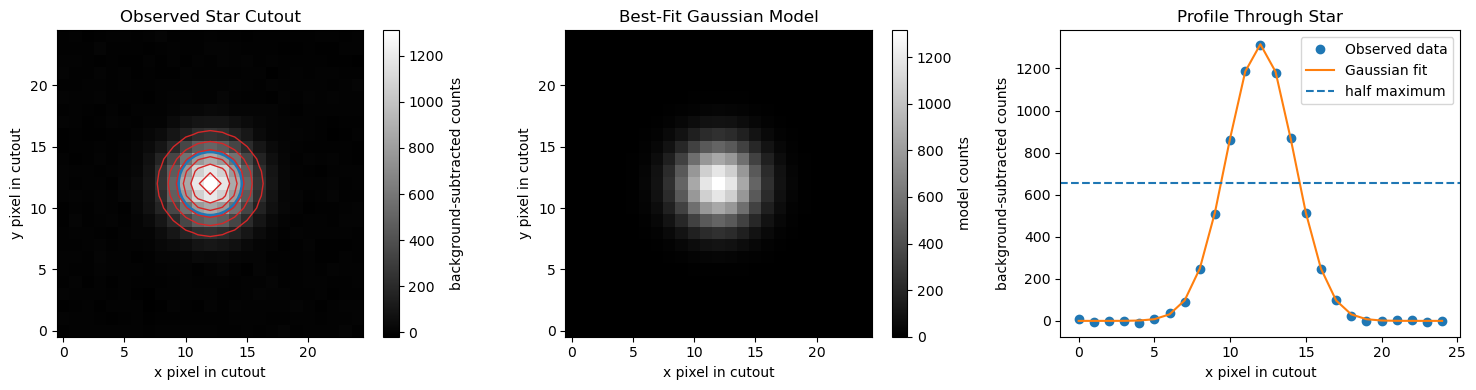

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: the observed star cutout.
im0 = axes[0].imshow(cutout_subtracted, origin="lower", cmap="gray")
axes[0].set_title("Observed Star Cutout")
axes[0].set_xlabel("x pixel in cutout")
axes[0].set_ylabel("y pixel in cutout")
axes[0].contour(gaussian_model, colors="tab:red", linewidths=1)
axes[0].add_patch(Circle((best_fit.x_mean.value, best_fit.y_mean.value), 0.5 * fwhm_average, fill=False, color="tab:blue", linewidth=2))
fig.colorbar(im0, ax=axes[0], label="background-subtracted counts")

# Panel 2: the best-fit two-dimensional Gaussian model.
im1 = axes[1].imshow(gaussian_model, origin="lower", cmap="gray")
axes[1].set_title("Best-Fit Gaussian Model")
axes[1].set_xlabel("x pixel in cutout")
axes[1].set_ylabel("y pixel in cutout")
fig.colorbar(im1, ax=axes[1], label="model counts")

# Panel 3: horizontal slice through the observed star and fitted model.
row = int(round(best_fit.y_mean.value))
axes[2].plot(x[row, :], cutout_subtracted[row, :], "o", label="Observed data")
axes[2].plot(x[row, :], gaussian_model[row, :], "-", label="Gaussian fit")
axes[2].axhline(0.5 * best_fit.amplitude.value, linestyle="--", label="half maximum")
axes[2].set_title("Profile Through Star")
axes[2].set_xlabel("x pixel in cutout")
axes[2].set_ylabel("background-subtracted counts")
axes[2].legend()

plt.tight_layout()
plt.show()

In the first panel, the red contours show the fitted Gaussian model on top of the observed star image. The blue circle has a radius of about half the average FWHM. This circle is not meant to be the final photometry aperture. It is only a visual guide showing the approximate width of the star image.

The profile plot shows why the FWHM is called the full width at half maximum. The Gaussian model has a peak value, and the FWHM is the width of the profile where the model drops to half of that peak value.

The factor $2.355$ converts the Gaussian standard deviation $\sigma$ into FWHM:

$$
{\rm FWHM} = 2\sqrt{2\ln 2}\,\sigma \approx 2.355\sigma.
$$

If the fitted FWHM values in the $x$ and $y$ directions are similar, the star is approximately round. If they are very different, the star may be elongated because of guiding error, wind shake, poor focus, or motion during the exposure. For asteroids, elongation can also happen if the asteroid moves noticeably during the exposure.

```{admonition} Practical rule
:class: tip

Use the FWHM measurement to choose a starting aperture size, then check whether the resulting light curve improves or gets worse when the aperture is made slightly smaller or larger.
```

A reasonable first aperture radius is often about $1.5$ to $2.0$ times the average FWHM.

### Using FWHM to choose an aperture

The code below uses the measured FWHM to suggest a starting aperture radius and sky annulus. These values should still be checked by inspecting the image.

In [7]:
aperture_radius = 1.5 * fwhm_average
sky_inner_radius = 3.0 * fwhm_average
sky_outer_radius = 5.0 * fwhm_average

print(f"Suggested aperture radius: {aperture_radius:.1f} pixels")
print(f"Suggested inner sky-annulus radius: {sky_inner_radius:.1f} pixels")
print(f"Suggested outer sky-annulus radius: {sky_outer_radius:.1f} pixels")

Suggested aperture radius: 7.7 pixels
Suggested inner sky-annulus radius: 15.5 pixels
Suggested outer sky-annulus radius: 25.8 pixels


These are starting values, not universal rules. After choosing an aperture, check whether the aperture contains the star's light, avoids nearby stars, and gives stable differential photometry.

```{admonition} Practical rule
:class: tip

Use FWHM to choose an initial aperture, then test whether the resulting light curve improves or gets worse when the aperture is made slightly smaller or larger.
```

## Differential Photometry

Differential photometry compares a target star to one or more comparison stars in the same image. This is powerful because the target and comparison stars pass through nearly the same atmosphere, are recorded by the same detector, and are affected by many of the same observing conditions.

The basic differential magnitude is

$$\Delta m = m_{\rm target} - \langle m_{\rm comp}\rangle.$$

If the target becomes fainter, its magnitude increases, so $\Delta m$ becomes larger. If the target becomes brighter, $\Delta m$ decreases.

Good comparison stars should be non-variable, unsaturated, reasonably bright, isolated, and preferably similar in color to the target. A check star is another non-variable star used to test whether the comparison-star system is stable.

```{admonition} Practical rule
:class: warning

Do not trust a comparison star just because it is convenient. Plot comparison minus check star. If that curve has a trend or unexplained structure, your comparison system may be part of the problem.
```

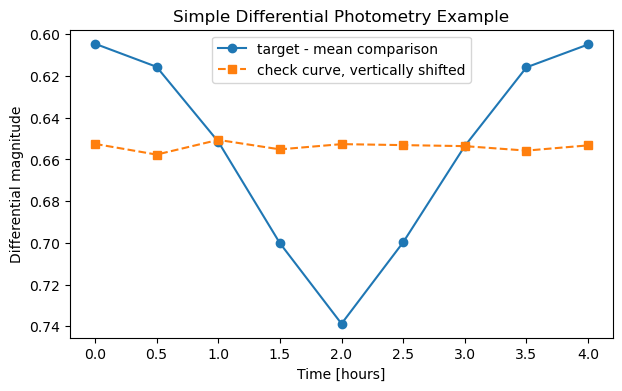

In [8]:
# Example differential magnitude calculation from measured source fluxes.
target_flux = np.array([9500, 9400, 9100, 8700, 8400, 8700, 9100, 9400, 9500], dtype=float)
comp1_flux = np.array([18200, 18150, 18220, 18180, 18210, 18190, 18230, 18170, 18200], dtype=float)
comp2_flux = np.array([15100, 15130, 15090, 15120, 15110, 15100, 15140, 15120, 15110], dtype=float)
time_hours = np.linspace(0, 4, len(target_flux))

target_mag = -2.5 * np.log10(target_flux)
comp1_mag = -2.5 * np.log10(comp1_flux)
comp2_mag = -2.5 * np.log10(comp2_flux)
mean_comp_mag = np.mean([comp1_mag, comp2_mag], axis=0)
delta_mag = target_mag - mean_comp_mag
check_minus_comp = comp1_mag - comp2_mag

fig, ax = plt.subplots(figsize=(7, 4),dpi=100)
ax.plot(time_hours, delta_mag, "o-", label="target - mean comparison")
ax.plot(time_hours, check_minus_comp - np.mean(check_minus_comp) + np.mean(delta_mag), "s--", label="check curve, vertically shifted")
ax.invert_yaxis()
ax.set_xlabel("Time [hours]")
ax.set_ylabel("Differential magnitude")
ax.set_title("Simple Differential Photometry Example")
ax.legend()
plt.show()

## Noise Sources in Photometry

Noise is any variation that makes the measured brightness differ from the true brightness. Some noise is random and can be reduced by collecting more photons or averaging repeated measurements. Other errors are systematic and must be avoided, calibrated, modeled, or flagged.

Random noise includes photon `shot noise` from the target, photon shot noise from the sky background, dark-current noise, read noise, and scintillation. Systematic effects include saturation, nonlinearity, poor flat-field correction, bad pixels, cosmic rays, tracking errors, changing focus, clouds, color-dependent extinction, and variable comparison stars.

```{admonition} Key idea
:class: note

Calibration frames do not remove all noise. They remove or correct repeatable instrumental signals. Random noise is still present after calibration, and noisy calibration frames can add noise to the final science image.
```

The ideal way to reduce random photon noise is to collect more photons without saturating the detector. That can mean longer exposures, more images, a larger telescope, or a brighter target. The practical limit is that long exposures can saturate bright comparison stars, trail moving targets, blur under poor guiding, or average over short-timescale variability.

## Signal-to-Noise Ratio

The signal-to-noise ratio, or SNR, compares the useful source signal to the uncertainty in that signal. A simplified CCD SNR expression is

$$ {\rm SNR} = \frac{N_{\star}}{\sqrt{N_{\star} + n_{\rm pix}(N_{\rm sky} + N_{\rm dark} + R^2)}}. $$

Here $N_{\star}$ is the number of detected source electrons, $n_{\rm pix}$ is the number of pixels in the aperture, $N_{\rm sky}$ is the sky electrons per pixel, $N_{\rm dark}$ is the dark-current electrons per pixel, and $R$ is the read noise in electrons per pixel. This expression is simplified, but it captures the main tradeoff: a larger aperture includes more source light, but it also includes more sky, dark, and read noise.

A useful approximate conversion from SNR to magnitude uncertainty is

$$\sigma_m \approx \frac{1.0857}{\rm SNR}.$$

For example, ${\rm SNR}=100$ corresponds to about $0.011$ mag uncertainty, while ${\rm SNR}=50$ corresponds to about $0.022$ mag uncertainty.

```{admonition} Precision versus accuracy
:class: warning

High SNR means small random scatter. It does not guarantee that the measurement is accurate. A saturated star, bad flat field, poor comparison star, or uncorrected extinction effect can still produce a wrong answer with deceptively small scatter.
```

SNR =  10 gives an approximate magnitude uncertainty of 0.1086 mag.
SNR =  20 gives an approximate magnitude uncertainty of 0.0543 mag.
SNR =  50 gives an approximate magnitude uncertainty of 0.0217 mag.
SNR = 100 gives an approximate magnitude uncertainty of 0.0109 mag.
SNR = 200 gives an approximate magnitude uncertainty of 0.0054 mag.
SNR = 500 gives an approximate magnitude uncertainty of 0.0022 mag.


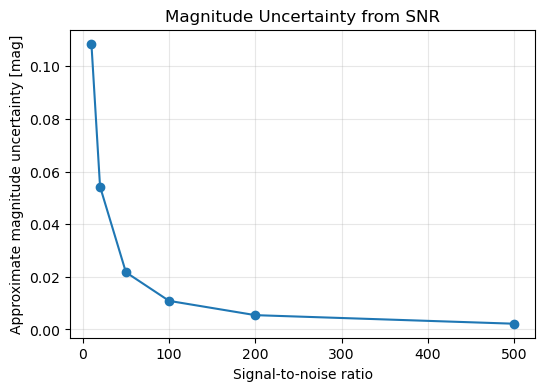

In [9]:
snr_values = np.array([10, 20, 50, 100, 200, 500])
mag_errors = 1.0857 / snr_values

for snr, err in zip(snr_values, mag_errors):
    print(f"SNR = {snr:3.0f} gives an approximate magnitude uncertainty of {err:.4f} mag.")

fig, ax = plt.subplots(figsize=(6, 4),dpi=100)
ax.plot(snr_values, mag_errors, "o-")
ax.set_xlabel("Signal-to-noise ratio")
ax.set_ylabel("Approximate magnitude uncertainty [mag]")
ax.set_title("Magnitude Uncertainty from SNR")
ax.grid(True, alpha=0.3)
plt.show()

## Calibration Frames

Calibration frames are images taken to measure detector and optical-system effects that are not part of the astronomical target. The three main calibration frames are bias, dark, and flat-field images.

A **bias frame** measures the electronic offset added during readout. It is taken with the shutter closed and the shortest possible exposure time. A **dark frame** measures thermal signal and hot pixels. It is taken with the shutter closed, usually at the same detector temperature, exposure time, binning, and readout mode as the science images. A **flat field** measures pixel-to-pixel sensitivity variations, dust shadows, and vignetting. It is taken through each filter using an evenly illuminated source.

```{admonition} Calibration frames at a glance
:class: tip

Bias frames correct the readout offset. Dark frames correct thermal signal and hot pixels. Flat fields correct uneven sensitivity across the detector and optical path.
```

A typical calibrated light image is

$$L_{\rm cal} = \frac{L_{\rm raw} - B_{\rm master} - D_{\rm scaled}}{F_{\rm norm}},$$

where $L_{\rm raw}$ is the raw light image, $B_{\rm master}$ is the master bias, $D_{\rm scaled}$ is the dark current scaled to the light exposure if needed, and $F_{\rm norm}$ is the normalized master flat. If your master dark already includes the bias and has the same exposure time as the science image, some pipelines subtract only the matched master dark and then divide by the normalized flat.

```{admonition} Important
:class: warning

Be consistent. Do not subtract the bias twice. If the master dark was made from raw darks and has the same exposure as the light images, it already contains the bias. If the master dark was bias-subtracted and scaled by exposure time, then subtract the master bias separately.
```

## How to Take Calibration Frames

Take multiple calibration frames and combine them into master frames. Combining many frames reduces random noise in the master calibration image.

| Frame type | Shutter | Light source | Match to science images | Main purpose |
|---|---|---|---|---|
| Bias | closed | none | binning, readout mode, temperature if possible | electronic readout offset |
| Dark | closed | none | exposure time, temperature, binning, readout mode | thermal signal and hot pixels |
| Flat | open | uniform illumination | filter, focus, camera angle, binning | pixel response, dust shadows, vignetting |
| Dark-flat | closed | none | flat exposure time and temperature | dark/bias correction for flats |

For beginner work, take many bias frames, a set of darks matched to each common science exposure time, and flats for every filter used. Flats should be bright enough to have good signal but not close to saturation. Avoid changing focus, rotating the camera, or moving dust between flats and lights.

```{admonition} Common beginner mistake
:class: warning

Do not use a flat from a different filter. Dust shadows and vignetting may look similar, but the detector and optics respond differently through different filters.
```

## The FITS File Format and Image Headers

Astronomical images are usually stored as **FITS files**, short for Flexible Image Transport System. A FITS file stores the image data and the metadata needed to understand the image. The image data are the pixel values. The metadata are stored in a **header** made of keyword-value-comment records. In Astropy, each header record is represented as a header card with a keyword, a value, and sometimes a comment.

For photometry, the header matters because the image by itself is not enough. You need to know when the exposure was taken, how long the exposure lasted, which filter was used, what type of frame it is, where the telescope was pointed, and sometimes whether calibration or plate-solving information has already been applied. A FITS header will not make bad data good, but it can prevent you from making avoidable mistakes.

```{admonition} Why beginners should read headers
:class: tip

Before calibrating or measuring images, check a few headers. Many beginner mistakes come from mixing filters, using the wrong exposure time, calibrating already-calibrated images, or assuming the observation time is correct without checking it.
```

### Public Example FITS File

The examples below use a public archival DSS image centered on Sirius. The image is useful for learning FITS structure and headers, but it is **not** a good precision-photometry example. Sirius is extremely bright, so the image may include saturation, halos, diffraction spikes, or other artifacts.

The example below downloads a public DSS2 Red FITS image centered on HD 209458, a well-known exoplanet-host star. This gives us a real archival FITS image without using unpublished observing data. The goal here is to practice reading the FITS file, inspecting the header, and displaying the image data.

The code uses [`astroquery.skyview`](https://astroquery.readthedocs.io/en/latest/skyview/skyview.html) to download a public FITS image from SkyView and [`astropy.io.fits`](https://docs.astropy.org/en/latest/io/fits/index.html) to read the FITS file.

In [ ]:
# If needed in Google Colab, uncomment the next line.
# !pip install astroquery

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astroquery.skyview import SkyView
from astropy import units as u
from astropy.io import fits
from astropy.visualization import ImageNormalize, ZScaleInterval, AsinhStretch
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Download a public archival FITS image centered on HD 209458.
target_name = "HD 209458"
survey_name = "DSS2 Red"
output_path = Path("example_hd209458_dss2_red.fits")

if not output_path.exists():
    print("Downloading public FITS image from SkyView...")
    images = SkyView.get_images(position=target_name, survey=[survey_name], radius=8 * u.arcmin, pixels=800)
    images[0].writeto(output_path, overwrite=True)
    print(f"Saved example FITS file to: {output_path}")
else:
    print(f"Using existing FITS file: {output_path}")

image_data, header = fits.getdata(output_path, header=True)
image_data = np.squeeze(image_data).astype(float)

Using existing FITS file: example_sirius_field_dss2_red.fits


### Inspecting the FITS File Structure

A FITS file is organized into one or more **Header Data Units**, usually called **HDUs**. Each HDU has a header, and many HDUs also contain data. For a simple image file, the data are usually stored as a two-dimensional array of pixel values.

Use `fits.info()` to see what is inside the file. This does not read the entire image into a variable for analysis. It prints a compact summary of the HDUs in the file.

In [11]:
fits.info(output_path)

Filename: example_sirius_field_dss2_red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     129   (800, 800)   float32   


For a simple image, you will usually see one primary HDU. More complicated FITS files may contain multiple extensions, such as science images, error arrays, data-quality masks, or tables. Space-telescope files often have several extensions, so do not assume that every FITS file stores the image in exactly the same place.

### Reading the Header and Image Data

The header stores metadata about the image. The data array stores the pixel values. The most common beginner mistake is to forget that NumPy arrays are indexed as `[y, x]`, not `[x, y]`.

In [12]:
# Read the image data and header.
image_data, header = fits.getdata(output_path, header=True)

# Remove any length-one dimensions and convert to floating-point values.
image_data = np.squeeze(image_data).astype(float)

print(f"Image shape: {image_data.shape}")
print(f"Data type: {image_data.dtype}")

Image shape: (800, 800)
Data type: float64


The image shape tells you the number of pixels in the image. For a two-dimensional image, the shape is usually reported as

```text
(number of y pixels, number of x pixels)
```

This order matters. In NumPy, image arrays are indexed as

```python
image_data[y, x]
```

not

```python
image_data[x, y]
```

### Reading Important Header Keywords

A FITS header is made of keyword-value pairs. Some keywords describe the file structure. Others describe the telescope, instrument, filter, exposure time, observation date, or sky coordinates. Different surveys and telescopes do not always use exactly the same keywords, so not every keyword will appear in every file.

In [13]:
useful_keywords = ["SIMPLE", "BITPIX", "NAXIS", "NAXIS1", "NAXIS2", "OBJECT", "DATE-OBS", "EXPTIME", "EXPOSURE", "FILTER", "TELESCOP", "INSTRUME", "CTYPE1", "CTYPE2", "CRVAL1", "CRVAL2", "CRPIX1", "CRPIX2", "CDELT1", "CDELT2"]

for key in useful_keywords:
    value = header.get(key, "not listed")
    comment = header.comments[key] if key in header else ""
    print(f"{key:8s} = {str(value):>24s}    {comment}")

SIMPLE   =                     True    Written by SkyView Fri May 15 10:32:26 EDT 2026
BITPIX   =                      -32    4 byte floating point
NAXIS    =                        2    Two dimensional image
NAXIS1   =                      800    Width of image
NAXIS2   =                      800    Height of image
OBJECT   =               not listed    
DATE-OBS =               not listed    
EXPTIME  =               not listed    
EXPOSURE =               not listed    
FILTER   =               not listed    
TELESCOP =               not listed    
INSTRUME =               not listed    
CTYPE1   =                 RA---TAN    Coordinates -- projection
CTYPE2   =                 DEC--TAN    Coordinates -- projection
CRVAL1   =                  101.287    Reference longitude
CRVAL2   =                 -16.7161    Reference latitude
CRPIX1   =                    400.5    X reference pixel
CRPIX2   =                    400.5    Y reference pixel
CDELT1   =   -0.0003333333333333334    X 

Some common FITS header keywords are:

<center>

| Keyword | Meaning |
|---|---|
| `SIMPLE` | Indicates that the file follows the basic FITS standard. |
| `BITPIX` | Describes the data type used to store pixel values. |
| `NAXIS` | Number of data axes. A normal image usually has `NAXIS = 2`. |
| `NAXIS1` | Number of pixels along the x-axis. |
| `NAXIS2` | Number of pixels along the y-axis. |
| `OBJECT` | Target or field name, if provided. |
| `DATE-OBS` | Observation date or start time, if provided. |
| `EXPTIME` or `EXPOSURE` | Exposure time, if provided. |
| `FILTER` | Filter used, if provided. |
| `TELESCOP` | Telescope or survey source, if provided. |
| `INSTRUME` | Instrument or camera, if provided. |
| `CTYPE1`, `CTYPE2` | Coordinate types for the image axes. |
| `CRVAL1`, `CRVAL2` | Sky coordinates at the reference pixel. |
| `CRPIX1`, `CRPIX2` | Reference pixel coordinates. |
| `CDELT1`, `CDELT2` | Approximate coordinate scale per pixel. |

</center>

```{admonition} Important
:class: warning

Do not assume that all FITS files use the same header keywords. Always inspect the header before writing code that depends on a specific keyword.
```

The WCS-related keywords, such as `CTYPE1`, `CTYPE2`, `CRVAL1`, `CRVAL2`, `CRPIX1`, and `CRPIX2`, help map pixel positions to sky coordinates. If those keywords are missing or unreliable, software may not know where the image is on the sky. That is one reason plate solving with tools such as Astrometry.net can be useful in a real observing workflow.

### Checking the Full Header

Sometimes you need to inspect the full header because the keyword you need is not in a short list. Printing the full header is useful, but it can be long.

In [14]:
# Print the first 40 header cards.
for card in header.cards[:40]:
    print(card)

SIMPLE  =                    T / Written by SkyView Fri May 15 10:32:26 EDT 2026
BITPIX  =                  -32 / 4 byte floating point                          
NAXIS   =                    2 / Two dimensional image                          
NAXIS1  =                  800 / Width of image                                 
NAXIS2  =                  800 / Height of image                                
CRVAL1  =              101.287 / Reference longitude                            
CRVAL2  =             -16.7161 / Reference latitude                             
RADESYS = 'FK5     '           / Coordinate system                              
EQUINOX =               2000.0 / Epoch of the equinox                           
CTYPE1  = 'RA---TAN'           / Coordinates -- projection                      
CTYPE2  = 'DEC--TAN'           / Coordinates -- projection                      
CRPIX1  =                400.5 / X reference pixel                              
CRPIX2  =                400

A **header card** is one line of FITS metadata. It usually contains a keyword, a value, and sometimes a comment. A header can also contain history or comment cards that describe how the file was created or processed.

### Displaying the FITS Image

Raw FITS images often have a large range of pixel values. If you display the image with a simple linear scale, faint stars may be hard to see. A display stretch changes how the image is shown on the screen without changing the stored data values.

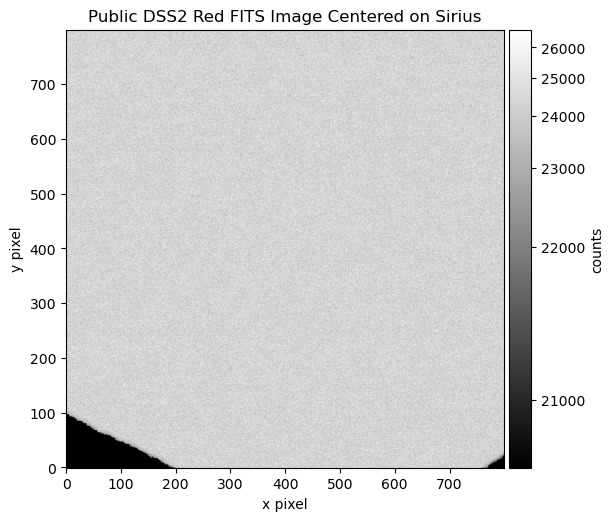

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)

norm = ImageNormalize(image_data, interval=ZScaleInterval(), stretch=AsinhStretch())
im = ax.imshow(image_data, origin="lower", cmap="gray", norm=norm)

ax.set_xlabel("x pixel")
ax.set_ylabel("y pixel")
ax.set_title("Public DSS2 Red FITS Image Centered on HD 209458")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax, label="counts")

plt.show()

The display stretch makes the image easier to inspect visually. It does not calibrate the image, remove noise, or change the actual pixel values.

```{admonition} Practical rule
:class: tip

Before analyzing a FITS image, check three things:

1. Does the image data look reasonable?
2. Does the header contain the time, filter, exposure, and coordinate information you need?
3. Are the pixel values raw, calibrated, or already processed by a survey pipeline?
```

### Summarizing a Folder of FITS Files

For a folder of FITS files, it is often helpful to build a small summary table before calibration. This lets you catch mismatched filters, exposure times, image types, or camera temperatures before the reduction goes too far.

The example below is a template for your own observing data. It assumes your files are stored in `data/raw/`.

In [29]:
from pathlib import Path
import pandas as pd

folder = Path("data/raw")
rows = []

for filename in sorted(folder.glob("*.fits")):
    hdr = fits.getheader(filename)
    rows.append({"file": filename.name, "object": hdr.get("OBJECT", ""), "type": hdr.get("IMAGETYP", ""), "date_obs": hdr.get("DATE-OBS", ""), "exptime": hdr.get("EXPTIME", hdr.get("EXPOSURE", "")), "filter": hdr.get("FILTER", ""), "temperature": hdr.get("CCD-TEMP", "")})

summary = pd.DataFrame(rows)
summary.head()

""


```{admonition} Header warning
:class: warning

Do not edit FITS headers casually. Header changes can affect timing, calibration, plate solving, and photometry. If a header must be corrected, keep a copy of the original file and record exactly what was changed.
```

## Python Setup

The examples below use NumPy, Matplotlib, and Astropy. The first example simulates data so that the notebook can run without real FITS images. The later examples show the same ideas for actual FITS files.

```{admonition} Optional packages
:class: note

For production image reduction, consider `ccdproc`, an Astropy-affiliated package designed for CCD calibration workflows. For aperture photometry, consider `photutils`, which provides aperture and PSF photometry tools. The examples below keep the core calibration steps explicit so that you can see what the code is doing.
```

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from pathlib import Path

rng = np.random.default_rng(123)

## Example 1: Simulate Raw Lights and Calibration Frames

The next cell creates a simplified fake dataset. The simulated science image contains stars, sky background, a bias pattern, dark current, hot pixels, pixel-response variations, and noise. This is not meant to be a perfect detector model. It is meant to show why calibration frames are needed.

The fake dataset includes raw light images, raw bias frames, raw dark frames, raw flat frames, and the hidden "true" star image used for comparison.

In [18]:
def gaussian_star(x, y, x0, y0, flux, sigma):
    return flux / (2 * np.pi * sigma**2) * np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))

ny, nx = 120, 120
y, x = np.mgrid[0:ny, 0:nx]
light_exptime = 60.0
dark_exptime = 60.0
flat_exptime = 5.0

bias_level = 1000.0
bias_pattern = bias_level + 8.0 * np.sin(2 * np.pi * x / nx)
dark_rate = 0.08
hot_pixel_map = np.zeros((ny, nx))
hot_pixel_map[rng.integers(0, ny, 25), rng.integers(0, nx, 25)] = rng.uniform(50, 150, 25)
flat_response = 1.0 + 0.08 * (x - nx / 2) / nx + 0.05 * (y - ny / 2) / ny
flat_response *= 1.0 - 0.25 * np.exp(-((x - 85)**2 + (y - 35)**2) / (2 * 5.0**2))

true_sky = 250.0
true_stars = gaussian_star(x, y, 40, 58, 70000, 2.2) + gaussian_star(x, y, 75, 72, 50000, 2.5) + gaussian_star(x, y, 62, 38, 30000, 2.0)
true_light = true_sky + true_stars
raw_light_expectation = true_light * flat_response + bias_pattern + dark_rate * light_exptime + hot_pixel_map
raw_lights = rng.poisson(raw_light_expectation, size=(8, ny, nx)).astype(float)
raw_biases = rng.normal(bias_pattern, 4.0, size=(30, ny, nx))
raw_darks = rng.poisson(bias_pattern + dark_rate * dark_exptime + hot_pixel_map, size=(20, ny, nx)).astype(float)
raw_flats = rng.poisson(25000.0 * flat_response + bias_pattern + dark_rate * flat_exptime + hot_pixel_map, size=(20, ny, nx)).astype(float)

print(f"Raw light stack shape: {raw_lights.shape}")
print(f"Raw bias stack shape: {raw_biases.shape}")
print(f"Raw dark stack shape: {raw_darks.shape}")
print(f"Raw flat stack shape: {raw_flats.shape}")

Raw light stack shape: (8, 120, 120)
Raw bias stack shape: (30, 120, 120)
Raw dark stack shape: (20, 120, 120)
Raw flat stack shape: (20, 120, 120)


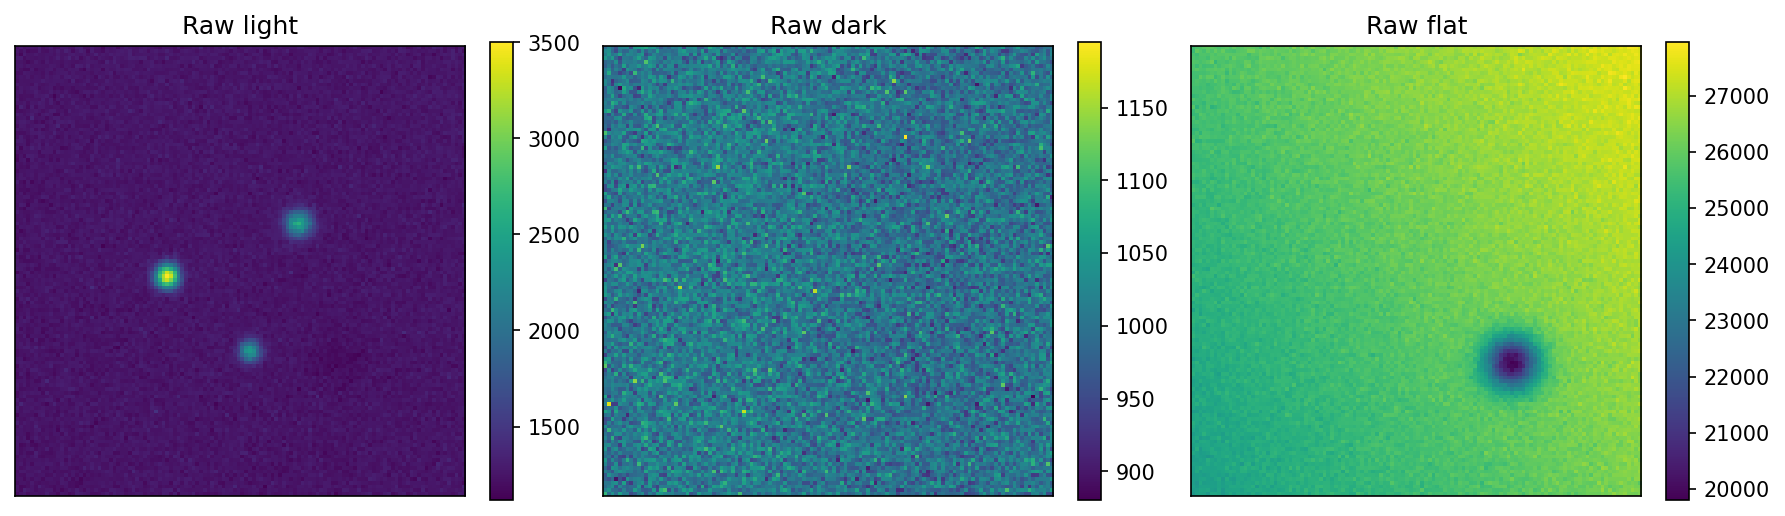

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4),dpi=150)
for ax, data, title in zip(axes, [raw_lights[0], raw_darks[0], raw_flats[0]], ["Raw light", "Raw dark", "Raw flat"]):
    im = ax.imshow(data, origin="lower")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Example 2: Build Master Calibration Frames

The standard beginner approach is to combine many frames using a median. A median is robust against cosmic rays and occasional bad frames. In real work, inspect the frames before combining them.

The master dark below is bias-subtracted, so it represents dark current plus hot pixels. The master flat is corrected by subtracting the master bias and a scaled version of the master dark. Then it is normalized by its median so that a typical pixel has a flat value near 1.

In [20]:
master_bias = np.median(raw_biases, axis=0)
master_dark = np.median(raw_darks, axis=0) - master_bias
master_flat_raw = np.median(raw_flats, axis=0)
master_flat_corrected = master_flat_raw - master_bias - master_dark * (flat_exptime / dark_exptime)
master_flat_norm = master_flat_corrected / np.median(master_flat_corrected)

print(f"Master bias median: {np.median(master_bias):.2f} counts")
print(f"Master dark median: {np.median(master_dark):.2f} counts in {dark_exptime:.1f} s")
print(f"Normalized flat median: {np.median(master_flat_norm):.3f}")

Master bias median: 1000.02 counts
Master dark median: 4.69 counts in 60.0 s
Normalized flat median: 1.000


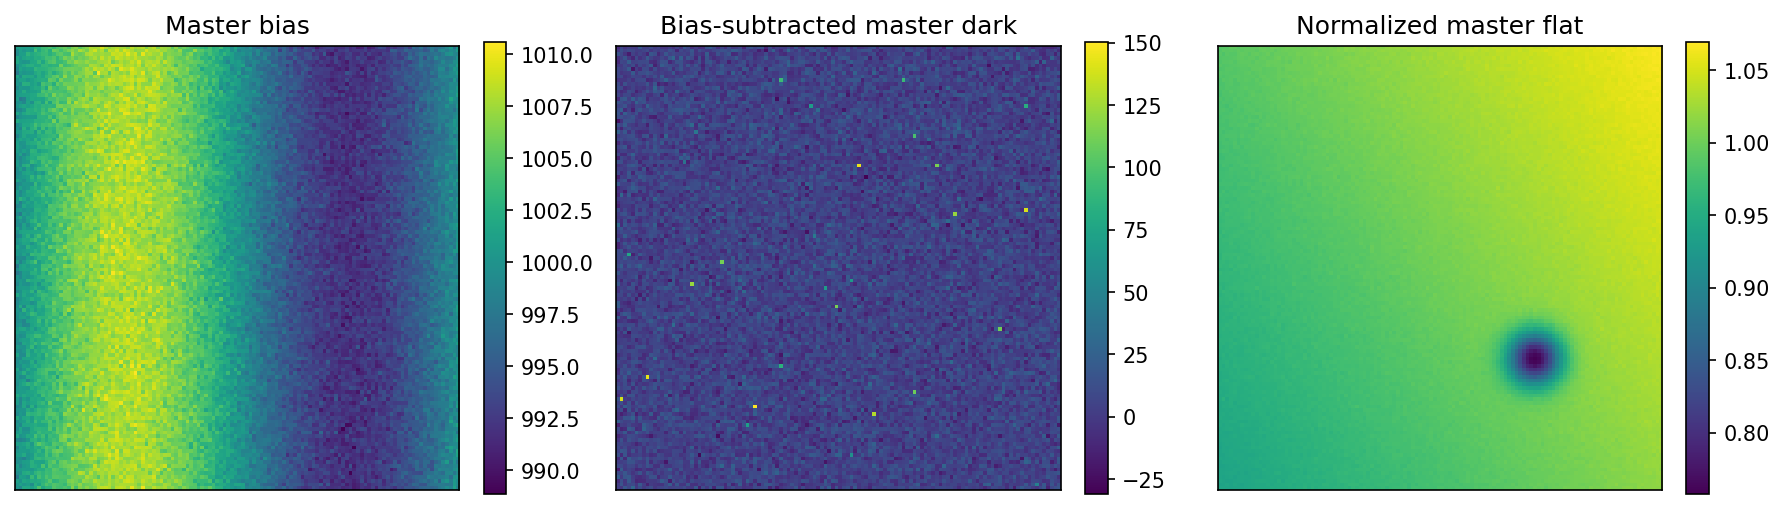

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4),dpi=150)
for ax, data, title in zip(axes, [master_bias, master_dark, master_flat_norm], ["Master bias", "Bias-subtracted master dark", "Normalized master flat"]):
    im = ax.imshow(data, origin="lower")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Example 3: Calibrate a Light Image

Now apply the calibration formula to one light image. Because the simulated master dark was bias-subtracted, the code subtracts the master bias separately and scales the master dark by exposure time.

```{admonition} Calibration formula
:class: note

For this example, the calibrated image is `calibrated = (raw_light - master_bias - scaled_dark) / master_flat_norm`.
```

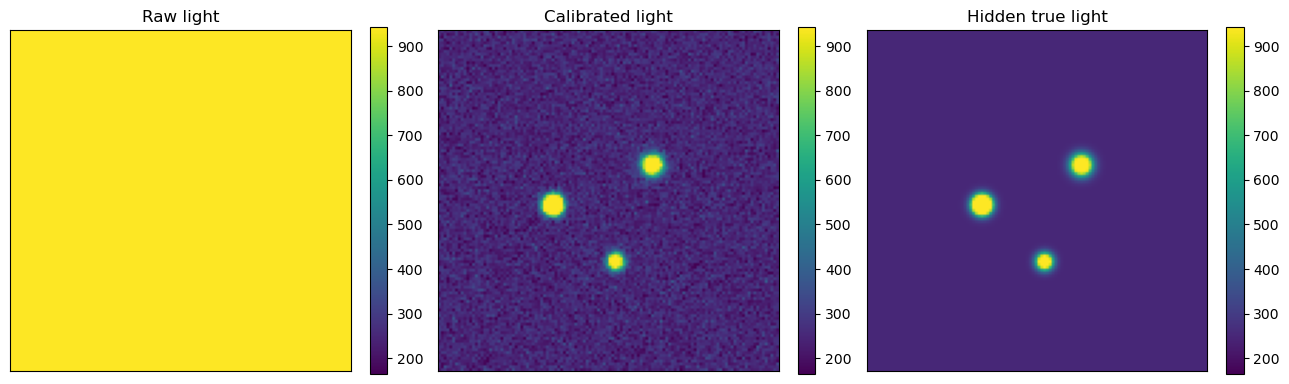

In [22]:
raw_light = raw_lights[0]
scaled_dark = master_dark * (light_exptime / dark_exptime)
calibrated_light = (raw_light - master_bias - scaled_dark) / master_flat_norm

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, data, title in zip(axes, [raw_light, calibrated_light, true_light], ["Raw light", "Calibrated light", "Hidden true light"]):
    im = ax.imshow(data, origin="lower", vmin=np.percentile(calibrated_light, 1), vmax=np.percentile(calibrated_light, 99.5))
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

In [23]:
residual_before = raw_light - np.median(raw_light)
residual_after = calibrated_light - true_light
print(f"Raw image median-subtracted scatter: {np.std(residual_before):.2f} counts")
print(f"Calibrated image residual scatter relative to hidden true image: {np.std(residual_after):.2f} counts")

Raw image median-subtracted scatter: 100.70 counts
Calibrated image residual scatter relative to hidden true image: 36.45 counts


## Example 4: Calibrating Real FITS Images with Astropy

The next example is a template for real data. It assumes a project directory with folders like this:

```text
photometry-project/
├── data/
│   ├── raw/
│   │   ├── bias/
│   │   ├── dark/
│   │   ├── flat_V/
│   │   └── light/
│   └── calibrated/
└── notebooks/
```

Before using this code, check your FITS headers. The exposure time keyword might be `EXPTIME`, `EXPOSURE`, or something else depending on the camera and acquisition software.

In [24]:
from astropy.io import fits
from pathlib import Path
import numpy as np

def read_fits_data(path):
    with fits.open(path) as hdul:
        data = hdul[0].data.astype(float)
        header = hdul[0].header.copy()
    return data, header

def median_combine_fits(paths):
    stack = []
    for path in paths:
        data, header = read_fits_data(path)
        stack.append(data)
    return np.median(np.array(stack), axis=0)

project = Path("photometry-project")
bias_paths = sorted((project / "data" / "raw" / "bias").glob("*.fit*"))
dark_paths = sorted((project / "data" / "raw" / "dark").glob("*.fit*"))
flat_paths = sorted((project / "data" / "raw" / "flat_V").glob("*.fit*"))
light_paths = sorted((project / "data" / "raw" / "light").glob("*.fit*"))

print(f"Found {len(bias_paths)} bias frames.")
print(f"Found {len(dark_paths)} dark frames.")
print(f"Found {len(flat_paths)} flat frames.")
print(f"Found {len(light_paths)} light frames.")

Found 0 bias frames.
Found 0 dark frames.
Found 0 flat frames.
Found 0 light frames.


The cell above will not do any reduction until the folder exists and contains FITS files. The next cell shows the reduction commands. Run it only after confirming that the paths are correct and that the frames belong together.

In [25]:
# Run this cell only after your file paths point to real FITS files.

if bias_paths and dark_paths and flat_paths and light_paths:
    master_bias = median_combine_fits(bias_paths)
    master_dark_raw = median_combine_fits(dark_paths)
    master_flat_raw = median_combine_fits(flat_paths)

    dark_header = read_fits_data(dark_paths[0])[1]
    flat_header = read_fits_data(flat_paths[0])[1]
    dark_exptime = float(dark_header.get("EXPTIME", dark_header.get("EXPOSURE", 1.0)))
    flat_exptime = float(flat_header.get("EXPTIME", flat_header.get("EXPOSURE", 1.0)))

    master_dark = master_dark_raw - master_bias
    master_flat_corrected = master_flat_raw - master_bias - master_dark * (flat_exptime / dark_exptime)
    master_flat_norm = master_flat_corrected / np.median(master_flat_corrected)

    output_dir = project / "data" / "calibrated"
    output_dir.mkdir(parents=True, exist_ok=True)

    for light_path in light_paths:
        light_data, light_header = read_fits_data(light_path)
        light_exptime = float(light_header.get("EXPTIME", light_header.get("EXPOSURE", 1.0)))
        calibrated = (light_data - master_bias - master_dark * (light_exptime / dark_exptime)) / master_flat_norm
        light_header.add_history("Calibrated using master bias, scaled master dark, and normalized master flat.")
        output_path = output_dir / f"calibrated_{light_path.name}"
        fits.writeto(output_path, calibrated.astype("float32"), light_header, overwrite=True)

    print(f"Wrote calibrated images to {output_dir}.")
else:
    print("The calibration cell did not run because one or more input folders are empty or missing.")

The calibration cell did not run because one or more input folders are empty or missing.


## Quality Checks After Calibration

Do not assume that calibration worked just because the code ran. Inspect the master frames and several calibrated science images. A master bias should show the electronic offset and readout structure but should not contain stars. A master dark should show thermal structure and hot pixels but should not contain sky signal. A normalized flat should have a median near 1 and should reveal dust shadows, vignetting, and pixel-response structure.

A calibrated light frame should have a flatter background than the raw image, but it does not need to look pretty. Negative background pixels can occur after calibration and sky subtraction. Do not automatically clip them to zero unless you have a specific reason.

```{admonition} Debugging checklist
:class: tip

If a calibrated image looks worse than the raw image, check whether the flat belongs to the same filter, whether the dark exposure time and temperature match, whether the image dimensions and binning match, whether the bias was subtracted twice, and whether any calibration frame was saturated.
```

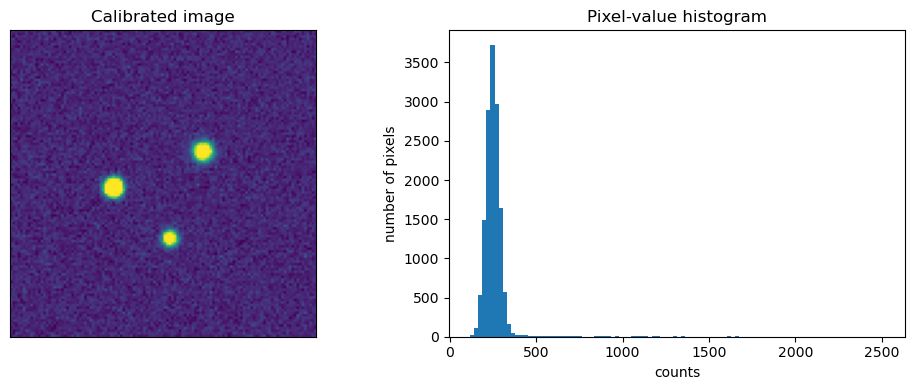

In [26]:
data = calibrated_light
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(data, origin="lower", vmin=np.percentile(data, 1), vmax=np.percentile(data, 99.5))
axes[0].set_title("Calibrated image")
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[1].hist(data.ravel(), bins=100)
axes[1].set_title("Pixel-value histogram")
axes[1].set_xlabel("counts")
axes[1].set_ylabel("number of pixels")
plt.tight_layout()
plt.show()

## From Calibrated Images to Differential Light Curves

Once the light frames are calibrated, the next steps are measuring the target and comparison stars, computing instrumental magnitudes, computing differential magnitudes, and plotting the result against time. This is where aperture choice, sky annulus choice, comparison-star choice, and time stamps become critical.

For a beginner workflow:

1. Calibrate every light image using the same method.
2. Identify the target star, at least one comparison star, and at least one check star.
3. Measure the target, comparison, and check stars with the same aperture settings.
4. Compute instrumental magnitudes from background-subtracted fluxes.
5. Compute target minus comparison and check minus comparison.
6. Plot both curves against time.
7. Inspect outliers before removing anything.

```{admonition} Important
:class: warning

Never delete suspicious data silently. If a point is removed because of clouds, bad tracking, saturation, cosmic rays, or a bad aperture placement, record the reason in the research log.
```

## Common Problems in Beginner Photometry

Many beginner photometry problems are not caused by complicated astrophysics. They come from ordinary reduction and measurement choices. Common issues include saturated target or comparison stars, using comparison stars that are variable or much different in color from the target, using an aperture that is too small, including a nearby star in the aperture or sky annulus, using flats from the wrong filter, failing to match dark exposure time or temperature, using images taken too low in the sky, and trusting a light curve before checking the raw images.

```{admonition} Rule of thumb
:class: tip

When the light curve looks strange, first check the images. Look for clouds, trailed stars, focus changes, cosmic rays, bad columns, saturation, comparison-star problems, and target motion across the detector.
```

## Videos and Further Reading

Use these resources when you need a slower explanation or a software demonstration.

### Differential photometry and aperture photometry

- [Boyce Astro: Differential Photometry](https://boyce-astro.org/differential-photometry/) — start here for the target/comparison-star idea.
- [Boyce Astro Videos: Photometry](https://boyce-astro.org/videos/photometry/) — includes aperture photometry, photometry overview, differential photometry, standard stars, Landolt standards, and extinction.
- [Boyce Astro Videos: Light Curves](https://boyce-astro.org/videos/light-curves/) — includes light-curve overview, light-curve analysis, and phase diagrams.
- [NITARP Tutorial: APT Overview](https://www.youtube.com/watch?v=5lXAWfBW_NQ) — overview of the Aperture Photometry Tool.
- [Using APT for Differential Photometry](https://www.youtube.com/watch?v=ITb3ohWv9U0) — short demonstration of APT-style differential photometry.
- [Intro to Light Curve Photometry with AstroImageJ](https://www.youtube.com/watch?v=zmJ04i06Rjc) — basic light-curve photometry workflow using AstroImageJ.

### Magnitudes and light curves

- [Launch Pad Astronomy: Stellar Magnitudes](https://www.youtube.com/watch?v=PcRLQ_QYbfM) — useful review of the magnitude scale.
- [Launch Pad Astronomy: Light playlist](https://www.youtube.com/playlist?list=PLrAnGxL8nxOH8Ye0IaioX67uv1ZvaOwaw) — background on light and how it behaves.
- [AAVSO: How To - Introductory Photometry](https://www.youtube.com/watch?v=OtiNNz2ghTI) — introductory webinar on photometry.
- [AAVSO How-To Hour: How to Start with CCD Photometry](https://www.youtube.com/watch?v=gcE7c4CggFM) — CCD photometry overview.

### Python documentation

- [Astropy CCD Data Reduction and Photometry Guide](https://www.astropy.org/ccd-reduction-and-photometry-guide/)
- [ccdproc documentation](https://ccdproc.readthedocs.io/)
- [Photutils documentation](https://photutils.readthedocs.io/)

## Final Checklist

Before trusting a photometric measurement, make sure the data pass the basic checks below.

```{admonition} Photometry checklist
:class: tip

- Were the light images calibrated with appropriate bias, dark, and flat frames?
- Were flats taken through the same filter as the light images?
- Were the target and comparison stars unsaturated?
- Were the target, comparison, and check stars measured consistently?
- Was the sky annulus free of obvious stars or bad pixels?
- Does the check-star curve look flat?
- Were suspicious points investigated in the images?
- Were rejected points documented in the research log?
```

Good photometry is not produced by one magic step. It is produced by many small checks that prevent detector behavior, atmosphere, and software choices from masquerading as astrophysics.